## 1. Import Required Libraries

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set matplotlib defaults
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.7
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['lines.markersize'] = 6
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['font.size'] = 11

print('✅ Libraries imported successfully')

✅ Libraries imported successfully


## 2. Load Metrics Data

In [2]:
# Algorithm name mapping
ALGORITHM_NAMES = {
    'gaussian_ppo': 'PPO',
    'gaussian_dql': 'DQL',
    'ppo_diffusion': 'DiffPPO',
    'ql_diffusion': 'DiffQL'
}

COLORS = {
    'gaussian_ppo': '#1f77b4',
    'gaussian_dql': '#ff7f0e',
    'ppo_diffusion': '#2ca02c',
    'ql_diffusion': '#d62728'
}

# Load convergence data
with open('backup_saved_plots/convergence_data.json', 'r') as f:
    convergence_data = json.load(f)

print(f'✅ Loaded data for {len(convergence_data)} algorithms:')
for alg in convergence_data.keys():
    num_episodes = len(convergence_data[alg]['rewards'])
    print(f'   - {ALGORITHM_NAMES.get(alg, alg)}: {num_episodes} episodes')

✅ Loaded data for 4 algorithms:
   - PPO: 1000 episodes
   - DiffQL: 1000 episodes
   - DQL: 1000 episodes
   - DiffPPO: 1000 episodes


## 3. Prepare Data for Plotting

In [3]:
# Create comprehensive statistics dataframe
stats_list = []

for alg, alg_data in convergence_data.items():
    rewards = np.array(alg_data['rewards'])
    first_100 = np.mean(rewards[:min(100, len(rewards))])
    last_100 = np.mean(rewards[-min(100, len(rewards)):])
    improvement = ((last_100 - first_100) / (abs(first_100) + 1e-6)) * 100
    
    stats_list.append({
        'Algorithm': ALGORITHM_NAMES.get(alg, alg),
        'Episodes': len(rewards),
        'Mean': np.mean(rewards),
        'Std': np.std(rewards),
        'Min': np.min(rewards),
        'Max': np.max(rewards),
        'Median': np.median(rewards),
        'Improvement %': improvement
    })

stats_df = pd.DataFrame(stats_list)
print('\n📊 Training Statistics:')
print(stats_df.to_string(index=False))


📊 Training Statistics:
Algorithm  Episodes       Mean        Std         Min        Max     Median  Improvement %
      PPO      1000 387.631811  74.765922  182.579297 587.929044 384.936877       0.243069
   DiffQL      1000 541.794707 158.483346 -773.784577 827.616394 554.760428       5.004317
      DQL      1000 532.597643  77.159561  345.145708 791.484783 528.716421     -18.657958
  DiffPPO      1000 521.766720 120.691762 -503.109512 824.235160 517.609019      -6.607903


## 4. Plot Training Metrics - Convergence Curves

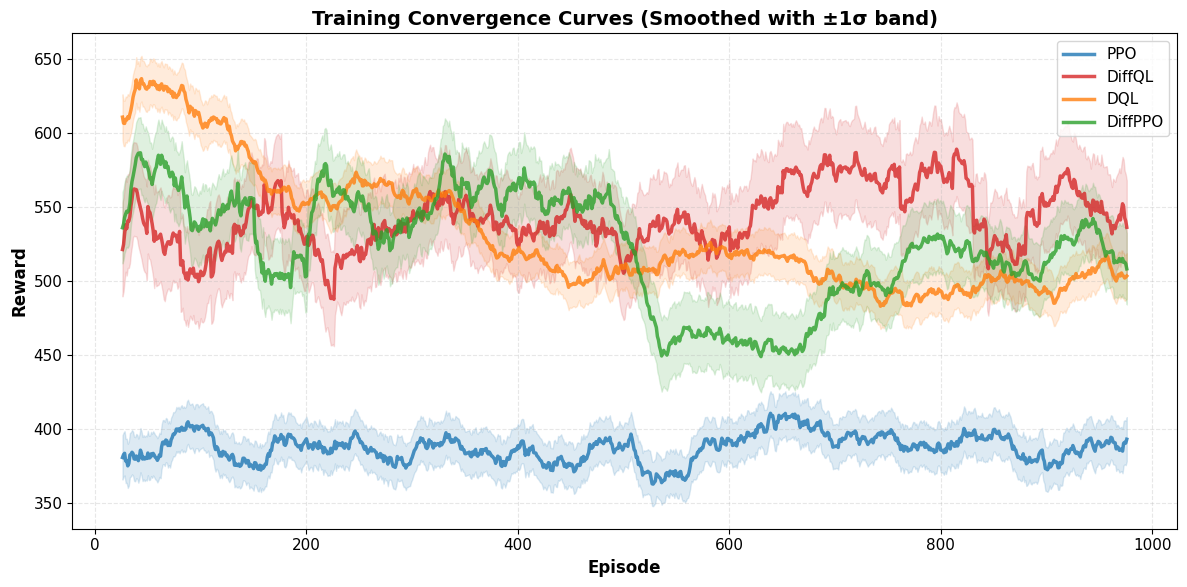

✅ Convergence curves plotted


In [4]:
# Plot convergence curves
fig, ax = plt.subplots(figsize=(12, 6))

for alg, alg_data in convergence_data.items():
    episodes = alg_data['episodes']
    rewards = alg_data['rewards']
    
    # Plot with smooth rolling average
    window = max(10, len(rewards) // 20)
    rolling_avg = pd.Series(rewards).rolling(window=window, center=True).mean()
    
    label = ALGORITHM_NAMES.get(alg, alg)
    ax.plot(episodes, rolling_avg, linewidth=2.5, label=label, 
            color=COLORS.get(alg, None), alpha=0.8)
    
    # Add confidence band (±std)
    ax.fill_between(episodes, rolling_avg - np.std(rewards)/5, 
                    rolling_avg + np.std(rewards)/5, 
                    alpha=0.15, color=COLORS.get(alg, None))

ax.set_xlabel('Episode', fontsize=12, fontweight='bold')
ax.set_ylabel('Reward', fontsize=12, fontweight='bold')
ax.set_title('Training Convergence Curves (Smoothed with ±1σ band)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/01_convergence_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print('✅ Convergence curves plotted')

## 5. Plot Validation Metrics - Reward Distribution

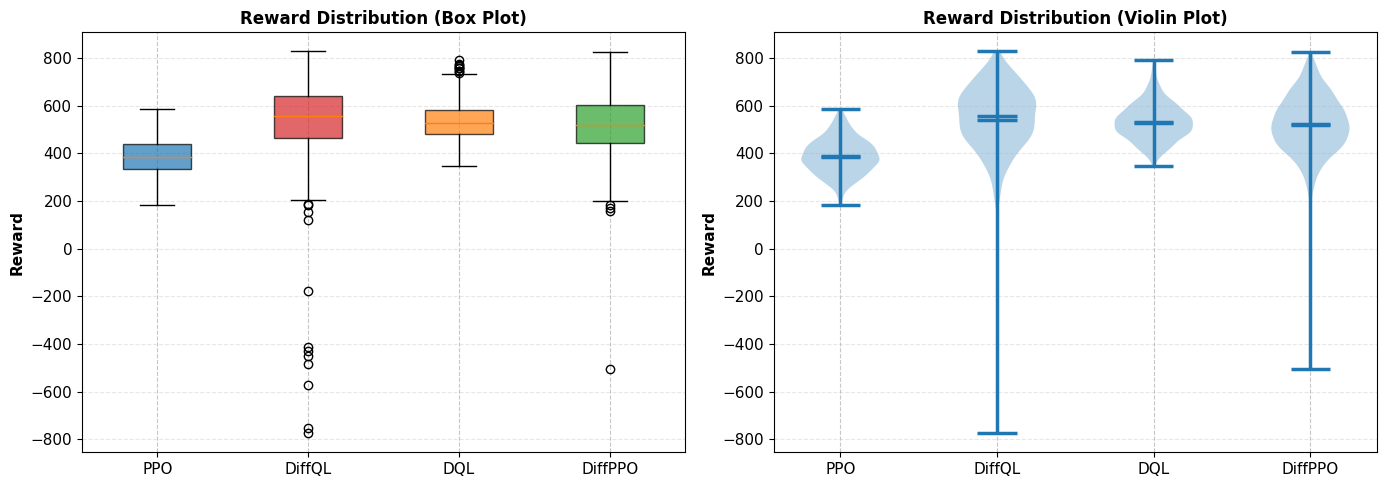

✅ Reward distribution plotted


In [5]:
# Plot reward distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prepare data
rewards_data = []
labels = []
for alg, alg_data in convergence_data.items():
    rewards_data.append(alg_data['rewards'])
    labels.append(ALGORITHM_NAMES.get(alg, alg))

# Box plot
bp = axes[0].boxplot(rewards_data, labels=labels, patch_artist=True)
for patch, alg in zip(bp['boxes'], convergence_data.keys()):
    patch.set_facecolor(COLORS.get(alg, '#808080'))
    patch.set_alpha(0.7)
axes[0].set_ylabel('Reward', fontsize=11, fontweight='bold')
axes[0].set_title('Reward Distribution (Box Plot)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Violin plot
parts = axes[1].violinplot(rewards_data, positions=range(len(rewards_data)), 
                            showmeans=True, showmedians=True)
axes[1].set_xticks(range(len(labels)))
axes[1].set_xticklabels(labels)
axes[1].set_ylabel('Reward', fontsize=11, fontweight='bold')
axes[1].set_title('Reward Distribution (Violin Plot)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('plots/02_reward_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print('✅ Reward distribution plotted')

## 6. Plot Comparison Metrics - Detailed Analysis

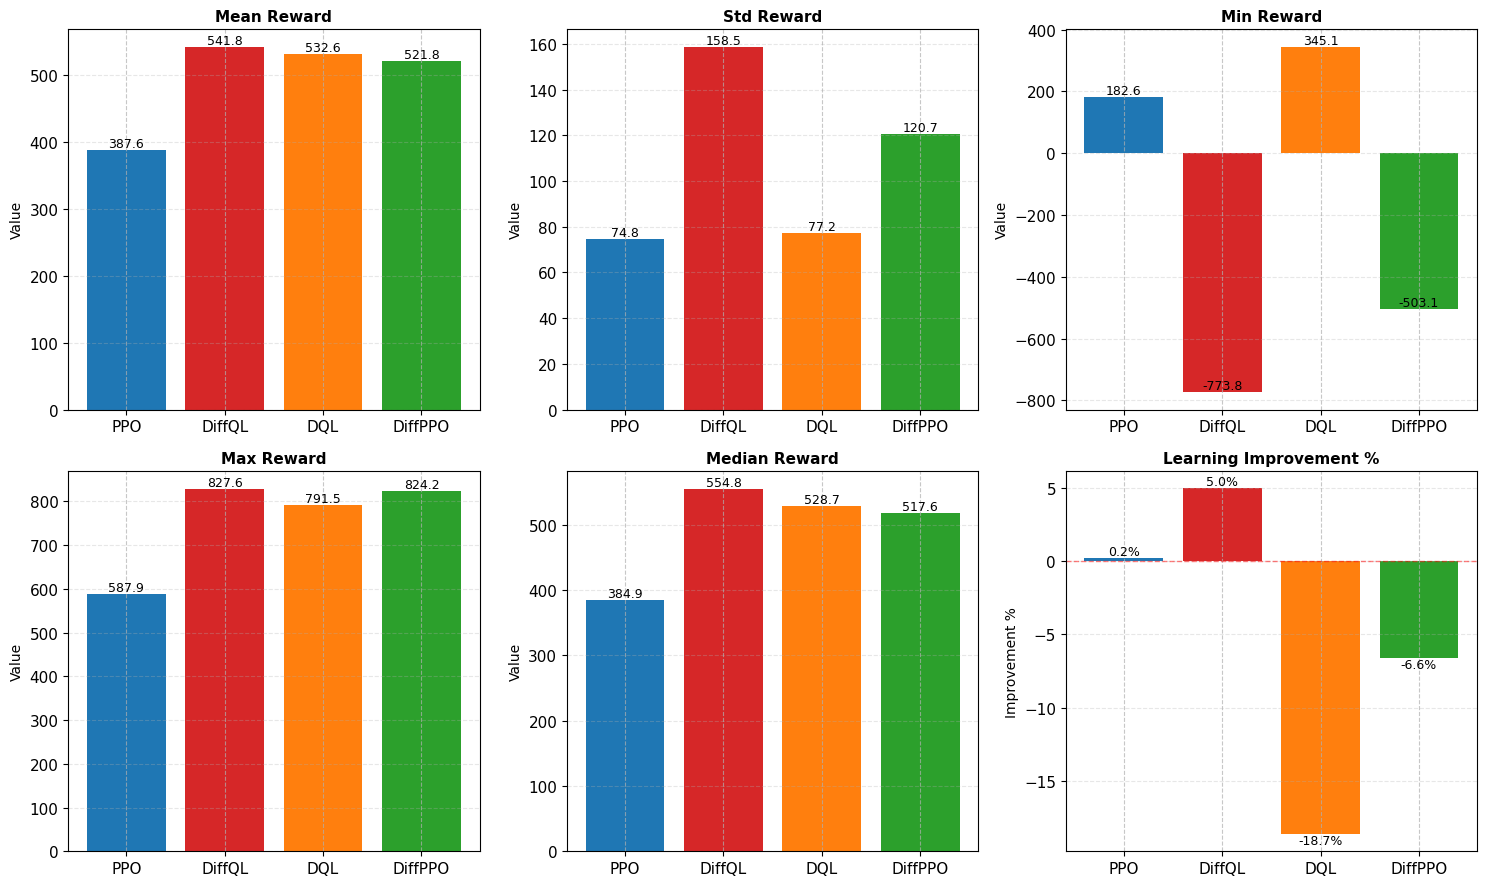

✅ Statistics comparison plotted


In [6]:
# Plot comprehensive statistics comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

metrics = ['Mean', 'Std', 'Min', 'Max', 'Median']
for idx, metric in enumerate(metrics):
    ax = axes[idx]
    bars = ax.bar(stats_df['Algorithm'], stats_df[metric], 
                  color=[COLORS.get(list(convergence_data.keys())[i], '#808080') 
                         for i in range(len(convergence_data))])
    ax.set_title(f'{metric} Reward', fontsize=11, fontweight='bold')
    ax.set_ylabel('Value', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.1f}', ha='center', va='bottom', fontsize=9)

# Plot learning improvement
ax = axes[-1]
improvements = stats_df['Improvement %'].values
bars = ax.bar(stats_df['Algorithm'], improvements,
              color=[COLORS.get(list(convergence_data.keys())[i], '#808080') 
                     for i in range(len(convergence_data))])
ax.set_title('Learning Improvement %', fontsize=11, fontweight='bold')
ax.set_ylabel('Improvement %', fontsize=10)
ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.grid(True, alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{height:.1f}%', ha='center', va='bottom' if height > 0 else 'top', fontsize=9)

plt.tight_layout()
plt.savefig('plots/03_statistics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print('✅ Statistics comparison plotted')

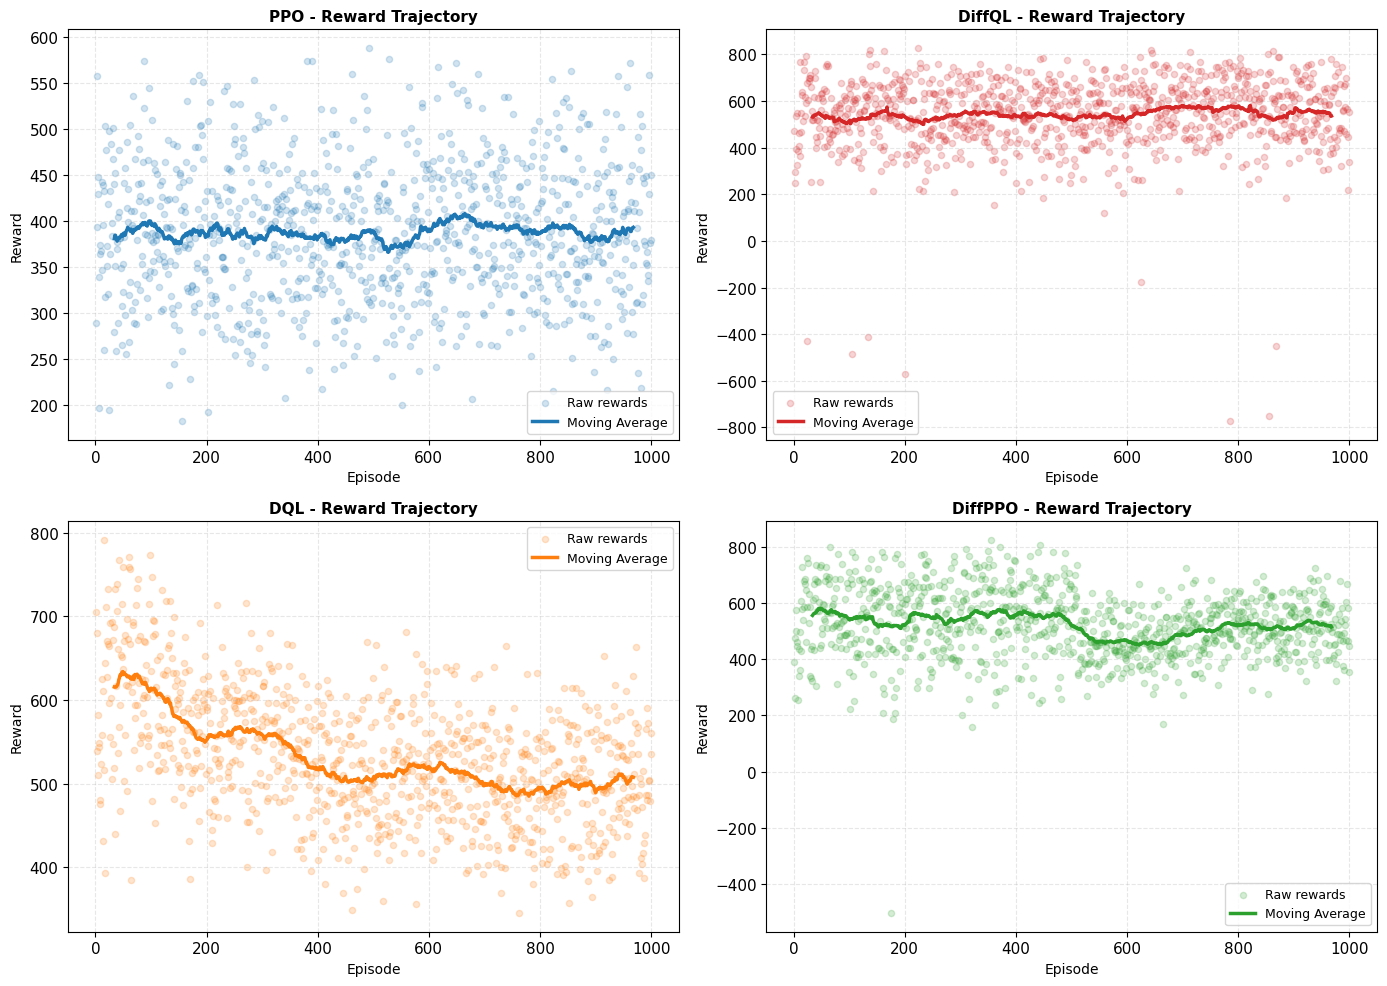

✅ Reward trajectories plotted


In [7]:
# Plot individual trajectories
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (alg, alg_data) in enumerate(convergence_data.items()):
    ax = axes[idx]
    episodes = np.array(alg_data['episodes'])
    rewards = np.array(alg_data['rewards'])
    
    # Raw rewards with transparency
    ax.scatter(episodes, rewards, alpha=0.2, s=20, 
              color=COLORS.get(alg, '#808080'), label='Raw rewards')
    
    # Moving average trend
    window = max(20, len(rewards) // 15)
    trend = pd.Series(rewards).rolling(window=window, center=True).mean()
    ax.plot(episodes, trend, linewidth=2.5, 
            color=COLORS.get(alg, '#808080'), label='Moving Average')
    
    ax.set_title(f'{ALGORITHM_NAMES.get(alg, alg)} - Reward Trajectory', 
                fontsize=11, fontweight='bold')
    ax.set_xlabel('Episode', fontsize=10)
    ax.set_ylabel('Reward', fontsize=10)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/04_reward_trajectories.png', dpi=300, bbox_inches='tight')
plt.show()

print('✅ Reward trajectories plotted')

## 7. Customize and Save Plots - Advanced Analytics

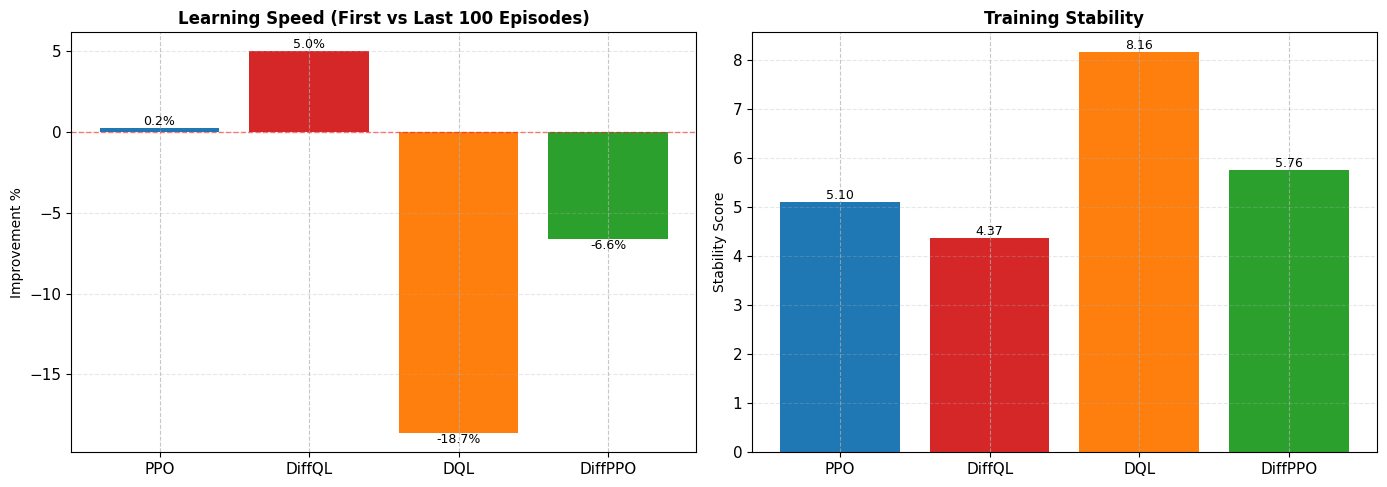

✅ Stability and speed analysis plotted


In [8]:
# Training stability and speed analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

learning_speeds = []
stabilities = []

for alg, alg_data in convergence_data.items():
    rewards = np.array(alg_data['rewards'])
    
    # Learning speed: improvement from first to last 100 episodes
    first_100 = np.mean(rewards[:min(100, len(rewards))])
    last_100 = np.mean(rewards[-min(100, len(rewards)):])
    learning_speed = ((last_100 - first_100) / (abs(first_100) + 1e-6)) * 100
    
    # Stability: inverse of coefficient of variation in last 100 episodes
    last_100_rewards = rewards[-min(100, len(rewards)):]
    stability = 1.0 / (np.std(last_100_rewards) / (np.mean(last_100_rewards) + 1e-6) + 1e-6)
    
    learning_speeds.append(learning_speed)
    stabilities.append(stability)

# Learning speed comparison
bars1 = axes[0].bar(stats_df['Algorithm'], learning_speeds,
                    color=[COLORS.get(alg, '#808080') for alg in convergence_data.keys()])
axes[0].set_title('Learning Speed (First vs Last 100 Episodes)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Improvement %', fontsize=10)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)

for i, bar in enumerate(bars1):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom' if height > 0 else 'top', fontsize=9)

# Stability comparison
bars2 = axes[1].bar(stats_df['Algorithm'], stabilities,
                    color=[COLORS.get(alg, '#808080') for alg in convergence_data.keys()])
axes[1].set_title('Training Stability', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Stability Score', fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')

for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('plots/05_stability_and_speed.png', dpi=300, bbox_inches='tight')
plt.show()

print('✅ Stability and speed analysis plotted')

In [9]:
# Generate comprehensive summary report
print("\n" + "="*80)
print("TRAINING METRICS COMPREHENSIVE REPORT")
print("="*80 + "\n")

for alg, alg_data in convergence_data.items():
    rewards = np.array(alg_data['rewards'])
    print(f"\n📊 {ALGORITHM_NAMES.get(alg, alg).upper()}")
    print("-" * 50)
    print(f"  Total Episodes: {len(rewards):,}")
    print(f"  Mean Reward: {np.mean(rewards):,.2f}")
    print(f"  Std Dev: {np.std(rewards):,.2f}")
    print(f"  Min Reward: {np.min(rewards):,.2f}")
    print(f"  Max Reward: {np.max(rewards):,.2f}")
    print(f"  Median: {np.median(rewards):,.2f}")
    print(f"  Q1 (25th percentile): {np.percentile(rewards, 25):,.2f}")
    print(f"  Q3 (75th percentile): {np.percentile(rewards, 75):,.2f}")
    print(f"  IQR: {np.percentile(rewards, 75) - np.percentile(rewards, 25):,.2f}")
    print(f"  Coefficient of Variation: {(np.std(rewards) / np.mean(rewards)) * 100:.2f}%")
    
    # Learning progress
    first_100 = np.mean(rewards[:min(100, len(rewards))])
    last_100 = np.mean(rewards[-min(100, len(rewards)):])
    improvement = ((last_100 - first_100) / (abs(first_100) + 1e-6)) * 100
    print(f"\n  Learning Progress:")
    print(f"    First 100 episodes avg: {first_100:,.2f}")
    print(f"    Last 100 episodes avg: {last_100:,.2f}")
    print(f"    Overall Improvement: {improvement:.2f}%")

print("\n" + "="*80)
print("✅ Report generation complete!")
print("="*80 + "\n")


TRAINING METRICS COMPREHENSIVE REPORT


📊 PPO
--------------------------------------------------
  Total Episodes: 1,000
  Mean Reward: 387.63
  Std Dev: 74.77
  Min Reward: 182.58
  Max Reward: 587.93
  Median: 384.94
  Q1 (25th percentile): 334.98
  Q3 (75th percentile): 438.47
  IQR: 103.49
  Coefficient of Variation: 19.29%

  Learning Progress:
    First 100 episodes avg: 389.01
    Last 100 episodes avg: 389.96
    Overall Improvement: 0.24%

📊 DIFFQL
--------------------------------------------------
  Total Episodes: 1,000
  Mean Reward: 541.79
  Std Dev: 158.48
  Min Reward: -773.78
  Max Reward: 827.62
  Median: 554.76
  Q1 (25th percentile): 463.84
  Q3 (75th percentile): 641.38
  IQR: 177.54
  Coefficient of Variation: 29.25%

  Learning Progress:
    First 100 episodes avg: 526.19
    Last 100 episodes avg: 552.52
    Overall Improvement: 5.00%

📊 DQL
--------------------------------------------------
  Total Episodes: 1,000
  Mean Reward: 532.60
  Std Dev: 77.16
  Min Re

## 8. QoS Sweep: Prices, Latency, QoS, Memory, Diffusion Steps

In [10]:
import os

# Load QoS sweep summary
qos_df = pd.read_csv('backup_saved_plots/qos_sweep_summary.csv')
qos_df['Agent'] = qos_df['Agent'].str.strip()
qos_df['Display'] = qos_df['Agent'].map(ALGORITHM_NAMES).fillna(qos_df['Agent'])
qos_df = qos_df.sort_values(['Agent', 'QoS_Target'])

os.makedirs('plots', exist_ok=True)

print('✅ QoS sweep data loaded')
print(qos_df.head())
print('\nAgents:', qos_df['Display'].unique())
print('QoS targets:', sorted(qos_df['QoS_Target'].unique()))

✅ QoS sweep data loaded
    QoS_Target  Users          Agent  Final_Reward  Avg_Memory  Avg_Latency  \
3         25.0     10  a2c_diffusion    443.713949    3.312946     1.166071   
9         30.0     10  a2c_diffusion    532.502355    3.444223     1.212259   
15        35.0     10  a2c_diffusion    630.383520    1.744076     0.587959   
4         25.0     10   bc_diffusion    452.929636    2.635067     0.941273   
10        30.0     10   bc_diffusion    553.672375    2.482783     0.875812   

      Avg_QoS  Avg_Denoise_Steps        Display  
3   12.769391              7.614  a2c_diffusion  
9   13.918412              7.260  a2c_diffusion  
15   5.138181              5.842  a2c_diffusion  
4    9.937029              6.288   bc_diffusion  
10   9.007535              6.210   bc_diffusion  

Agents: ['a2c_diffusion' 'bc_diffusion' 'gaussian_a2c' 'DQL' 'PPO' 'DiffQL']
QoS targets: [25.0, 30.0, 35.0]


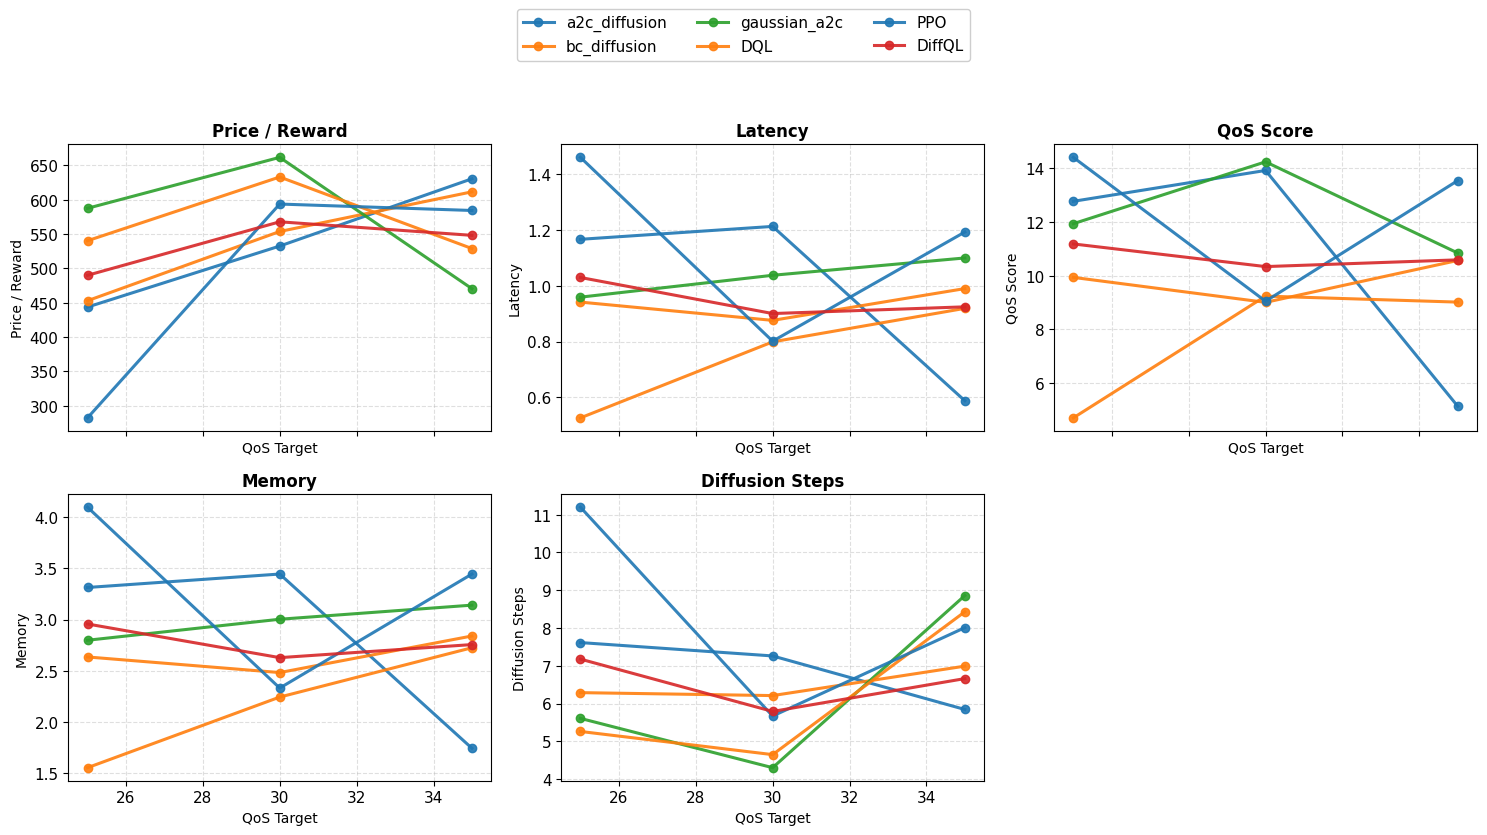

Saved: plots/06_qos_sweep_metrics.png


In [11]:
# Plot QoS sweep metrics: price/reward, latency, QoS, memory, diffusion steps
metrics = [
    ('Final_Reward', 'Price / Reward'),
    ('Avg_Latency', 'Latency'),
    ('Avg_QoS', 'QoS Score'),
    ('Avg_Memory', 'Memory'),
    ('Avg_Denoise_Steps', 'Diffusion Steps')
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
axes = axes.flatten()

for ax, (col, title) in zip(axes, metrics):
    for agent in qos_df['Agent'].unique():
        agent_df = qos_df[qos_df['Agent'] == agent].sort_values('QoS_Target')
        ax.plot(
            agent_df['QoS_Target'],
            agent_df[col],
            marker='o',
            linewidth=2.2,
            label=agent_df['Display'].iloc[0],
            color=COLORS.get(agent, None),
            alpha=0.9
        )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('QoS Target', fontsize=10)
    ax.set_ylabel(title, fontsize=10)
    ax.grid(True, alpha=0.4)

# Hide the last empty subplot if metrics < axes
if len(metrics) < len(axes):
    axes[-1].axis('off')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, frameon=True, framealpha=0.95, bbox_to_anchor=(0.5, 1.05))
plt.tight_layout(rect=(0, 0, 1, 0.92))

save_path = 'plots/06_qos_sweep_metrics.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {save_path}')

## 9. Convergence over Episodes: Price/Reward, Latency, QoS, Memory, Diffusion Steps

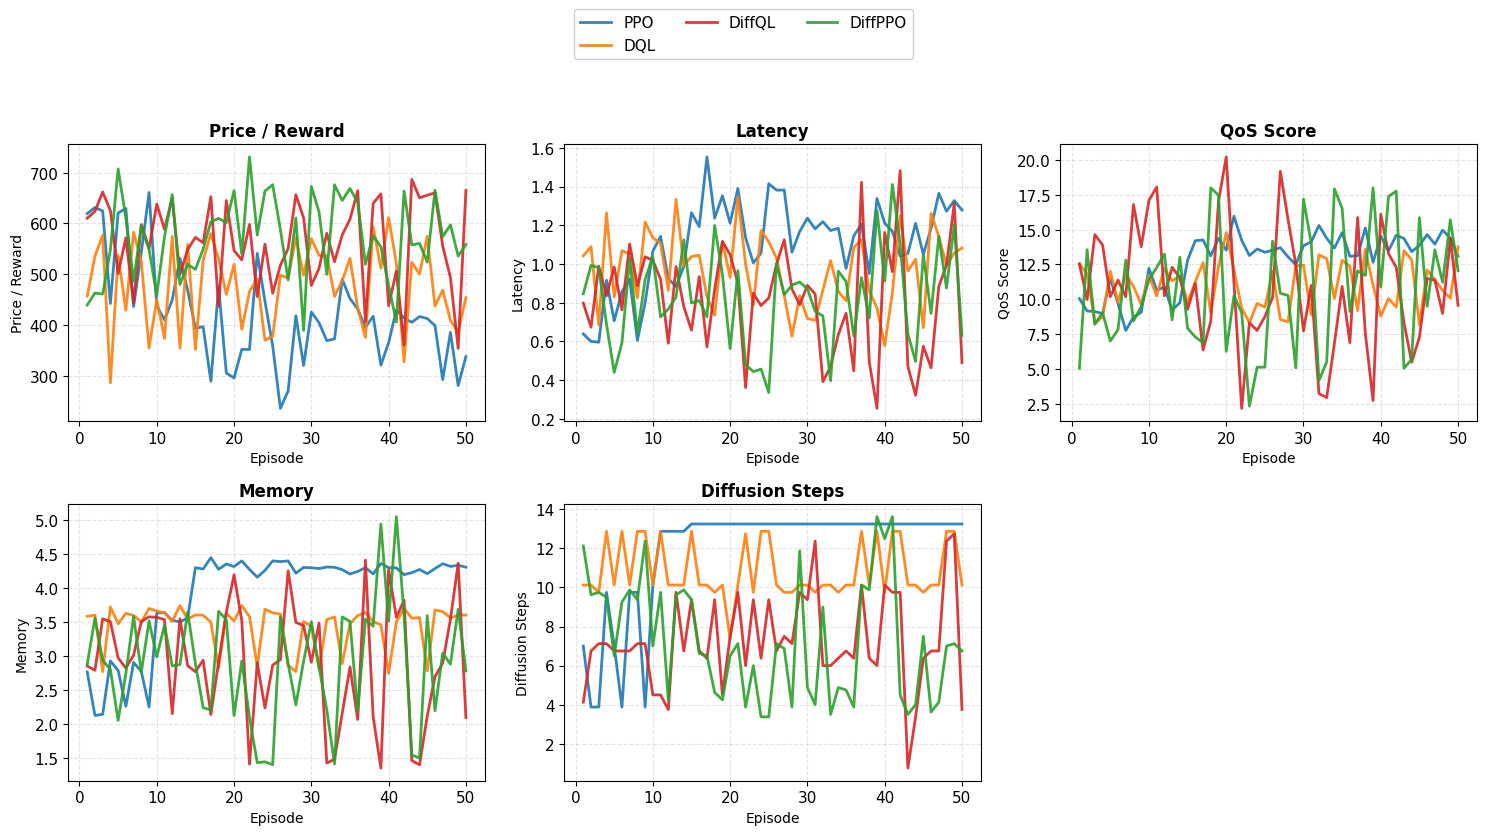

Saved: plots/07_qos_convergence_metrics.png


In [12]:
# Configure target QoS and user count for convergence plots
QOS_TARGET = 25.0  # change to another available target if needed
USER_KEY = '8'      # user count key in performance_analysis_qos_sweep.json

with open('backup_saved_plots/performance_analysis_qos_sweep.json', 'r') as f:
    qos_sweep = json.load(f)

if str(QOS_TARGET) not in qos_sweep:
    raise ValueError(f"QoS target {QOS_TARGET} not found in sweep data")
if USER_KEY not in qos_sweep[str(QOS_TARGET)]:
    raise ValueError(f"User key {USER_KEY} not found for QoS {QOS_TARGET}")

target_data = qos_sweep[str(QOS_TARGET)][USER_KEY]

metrics = [
    ('rewards', 'Price / Reward'),
    ('latency', 'Latency'),
    ('qos', 'QoS Score'),
    ('memory', 'Memory'),
    ('denoise_steps', 'Diffusion Steps')
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=False)
axes = axes.flatten()

for ax, (key, title) in zip(axes, metrics):
    for agent, vals in target_data.items():
        # Skip aggregated fields
        if not isinstance(vals, dict) or key not in vals:
            continue
        series = vals[key]
        episodes = np.arange(1, len(series) + 1)
        label = ALGORITHM_NAMES.get(agent, agent)
        ax.plot(
            episodes,
            series,
            linewidth=2.0,
            alpha=0.9,
            label=label,
            color=COLORS.get(agent, None)
        )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Episode', fontsize=10)
    ax.set_ylabel(title, fontsize=10)
    ax.grid(True, alpha=0.35)

# Hide extra subplot if any
if len(metrics) < len(axes):
    axes[-1].axis('off')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, frameon=True, framealpha=0.95, bbox_to_anchor=(0.5, 1.05))
plt.tight_layout(rect=(0, 0, 1, 0.92))

save_path = 'plots/07_qos_convergence_metrics.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {save_path}')

## 10. Reward Convergence Analysis across QoS Targets

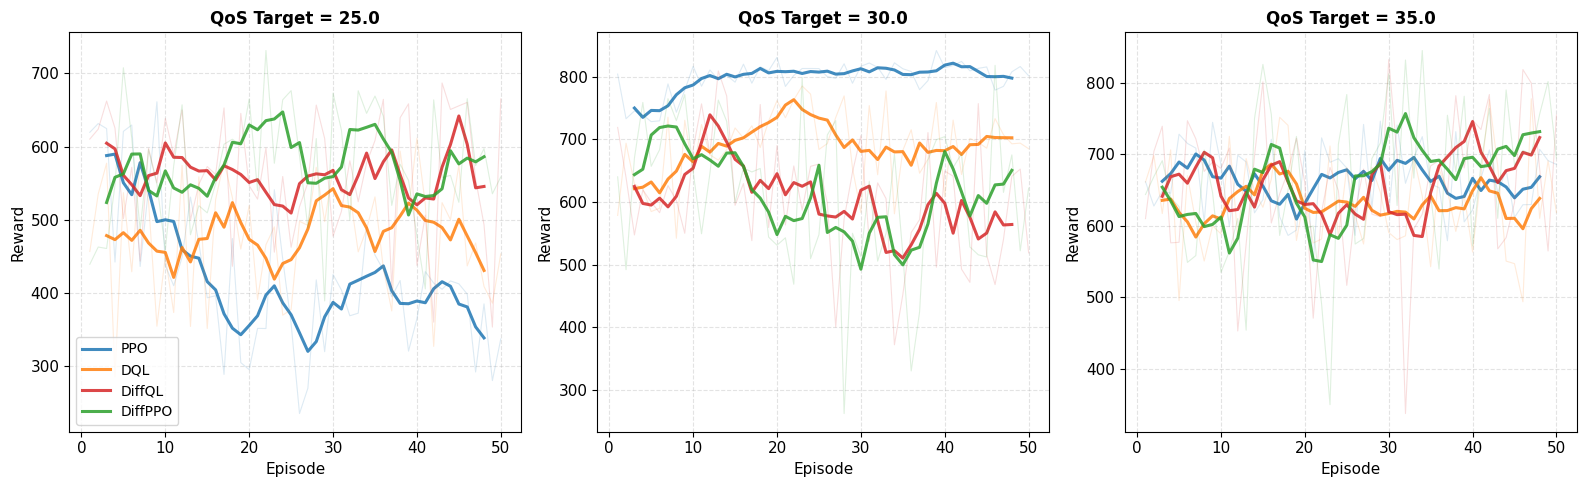

✅ Saved: plots/08_reward_convergence_qos_targets.png


In [13]:
# Plot reward convergence across multiple QoS targets
available_qos = sorted([float(k) for k in qos_sweep.keys()])
user_key = USER_KEY

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for qos_idx, qos_target in enumerate(available_qos):
    ax = axes[qos_idx]
    qos_key = str(qos_target)
    
    if qos_key not in qos_sweep or user_key not in qos_sweep[qos_key]:
        continue
    
    target_data = qos_sweep[qos_key][user_key]
    
    for agent, vals in target_data.items():
        if not isinstance(vals, dict) or 'rewards' not in vals:
            continue
        
        rewards = vals['rewards']
        episodes = np.arange(1, len(rewards) + 1)
        
        # Plot raw rewards with low alpha
        ax.plot(episodes, rewards, alpha=0.15, linewidth=0.8, color=COLORS.get(agent, None))
        
        # Plot smoothed curve (moving average)
        window = max(5, len(rewards) // 10)
        smoothed = pd.Series(rewards).rolling(window=window, center=True).mean()
        label = ALGORITHM_NAMES.get(agent, agent)
        ax.plot(episodes, smoothed, linewidth=2.2, label=label, color=COLORS.get(agent, None), alpha=0.85)
    
    ax.set_title(f'QoS Target = {qos_target}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Episode', fontsize=11)
    ax.set_ylabel('Reward', fontsize=11)
    ax.grid(True, alpha=0.35)
    
    if qos_idx == 0:
        ax.legend(loc='best', fontsize=10)

plt.tight_layout()
save_path = 'plots/08_reward_convergence_qos_targets.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {save_path}')